Loaded seismic array shape: (16, 600, 500)
Loaded source table shape: (500, 3)

PCA / POD Results (Unscaled)
Original waveform dim: 9600
Reduced dim          : 418
Explained variance   : 0.9995098

ROM coefficient RMSE: 7.666821134727306e-05

ROM Reconstruction Results
Waveform RMSE: 1.6001595165301775e-05


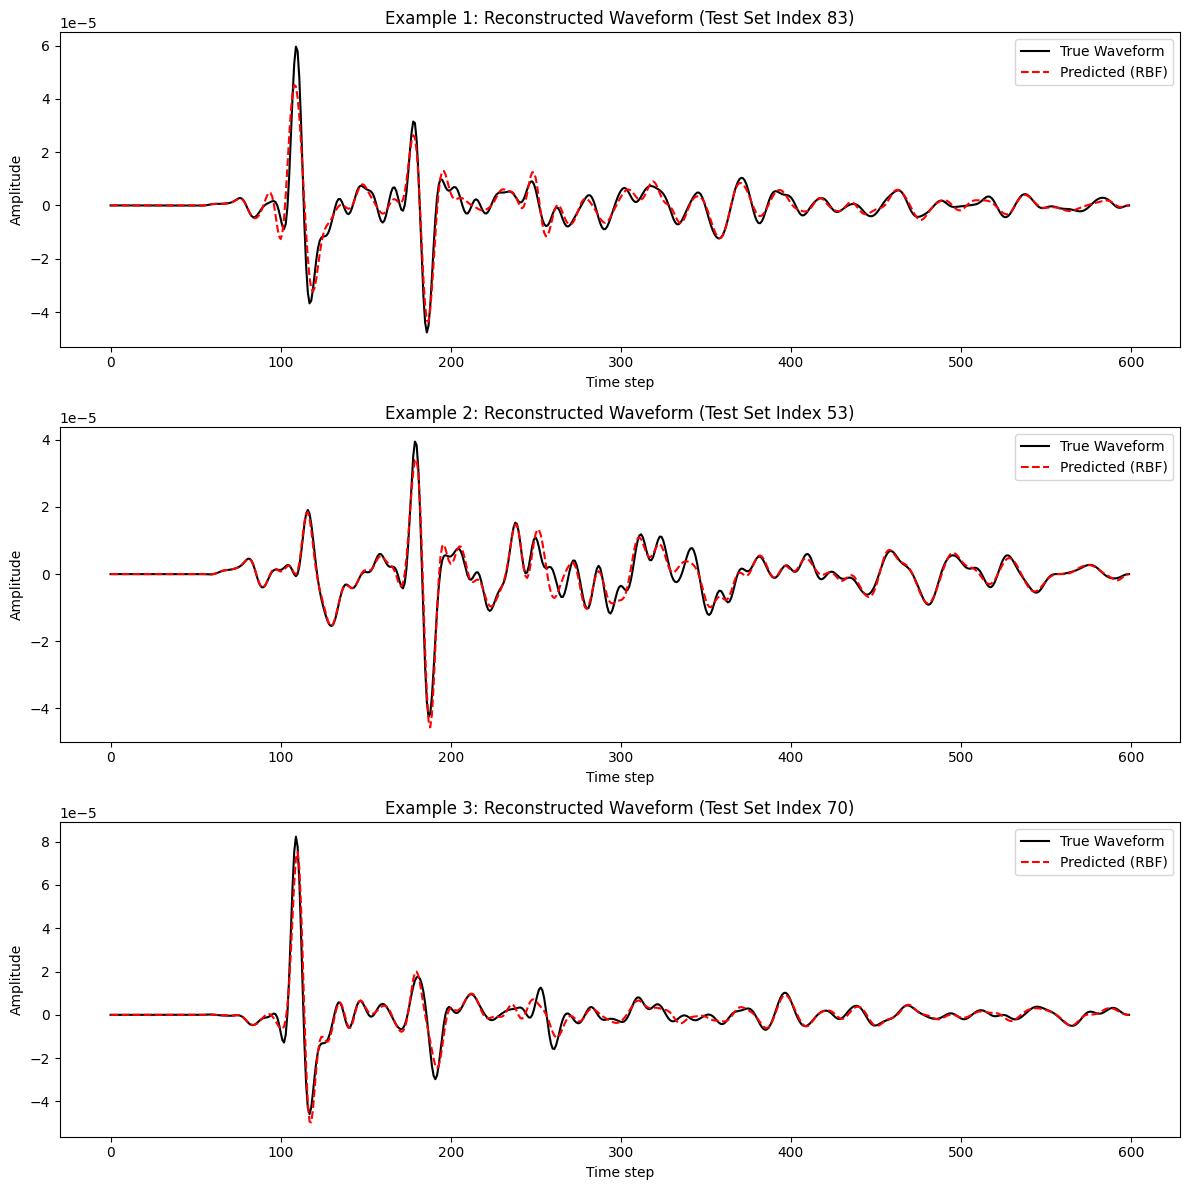


Saved artifacts to: /Users/nehalchoudhary/Desktop/datahacks-2026/artifacts


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from scipy.interpolate import RBFInterpolator


# =========================================================
# Custom RBF Wrapper for Scikit-Learn Pipeline
# =========================================================
class RBFWrapper(BaseEstimator, RegressorMixin):
    """
    Wraps Scipy's RBFInterpolator so it can be used like a Scikit-Learn model.
    Matches the authors' methodology exactly (using a cubic kernel).
    """
    def __init__(self, kernel='cubic', epsilon=None):
        self.kernel = kernel
        self.epsilon = epsilon
        self.interp_ = None
        self.X_train_ = None

    def fit(self, X, y):
        self.X_train_ = np.array(X)
        self.y_train_ = np.array(y)
        self.interp_ = RBFInterpolator(
            self.X_train_, 
            self.y_train_, 
            kernel=self.kernel,
            epsilon=self.epsilon
        )
        return self

    def predict(self, X):
        if self.interp_ is None:
            raise ValueError("The model is not fitted yet.")
        return self.interp_(np.array(X))


# =========================================================
# 1. LOAD + RESHAPE
# =========================================================

def load_data(seis_path="seismos_16_receivers.npy", src_path="source_locations.csv"):
    seis = np.load(seis_path, mmap_mode="r")
    src = pd.read_csv(src_path)

    print("Loaded seismic array shape:", seis.shape)
    print("Loaded source table shape:", src.shape)
    return seis, src


def fix_shape(seis, src):
    shape = seis.shape
    n_sources = len(src)

    if shape[2] == n_sources:
        fixed = np.transpose(seis, (2, 0, 1))
    elif shape[0] == n_sources:
        fixed = seis
    else:
        raise ValueError("Could not infer source axis.")

    return fixed.astype(np.float32)


def validate_and_clean(seis, src):
    seis = np.nan_to_num(seis, nan=0.0, posinf=0.0, neginf=0.0)
    mask = np.isfinite(seis).all(axis=(1, 2))
    seis = seis[mask]
    src = src.loc[mask].reset_index(drop=True)
    return seis, src


# =========================================================
# 2. FEATURES
# =========================================================

def build_feature_matrix(src):
    required = ["length", "width", "depth"]
    X = src[required].to_numpy(dtype=np.float32)
    return X


# =========================================================
# 3. TARGETS
# =========================================================

def compute_pgv_targets(seis):
    y_pgv = np.max(np.abs(seis), axis=-1).astype(np.float32)
    return y_pgv


def flatten_waveforms(seis):
    n_sources = seis.shape[0]
    Y = seis.reshape(n_sources, -1).astype(np.float32)
    return Y


# =========================================================
# 4. MODELS (PURE AUTHORS' METHODOLOGY - NO TARGET SCALING)
# =========================================================

def train_pgv_model(X, y_pgv):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_pgv, test_size=0.2, random_state=42
    )

    base_pipeline = Pipeline([
        ("scaler1", StandardScaler()), 
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler2", StandardScaler()),
        ("hgbr", MultiOutputRegressor(
            HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=42)
        ))
    ])

    model = TransformedTargetRegressor(
        regressor=base_pipeline,
        transformer=StandardScaler()
    )

    model.fit(X_train, y_train)
    return model


def fit_pca_rom(Y, variance_to_keep=0.9995):
    """
    REMOVED STANDARD SCALER. We are doing raw SVD/PCA directly on the 
    velocity matrix to perfectly match the authors' energy ratios.
    """
    pca = PCA(n_components=variance_to_keep, svd_solver="full")
    Z = pca.fit_transform(Y)

    print("\nPCA / POD Results (Unscaled)")
    print("Original waveform dim:", Y.shape[1])
    print("Reduced dim          :", Z.shape[1])
    print("Explained variance   :", pca.explained_variance_ratio_.sum())

    return pca, Z


def train_rom_model(X, Z):
    """
    Train: (length, width, depth) -> PCA coefficients.
    Removed TransformedTargetRegressor to prevent scaling the PCA targets.
    """
    X_train, X_test, Z_train, Z_test = train_test_split(
        X, Z, test_size=0.2, random_state=42
    )

    model_rom = Pipeline([
        ("scaler", StandardScaler()), # We still scale the 3D coordinates
        ("rbf", RBFWrapper(kernel='cubic')) 
    ])

    model_rom.fit(X_train, Z_train)
    Z_pred = model_rom.predict(X_test)

    coef_rmse = np.sqrt(mean_squared_error(Z_test, Z_pred))
    print("\nROM coefficient RMSE:", coef_rmse)

    return model_rom


# =========================================================
# 5. RECONSTRUCTION & EVALUATION (MULTIPLE EXAMPLES)
# =========================================================

def reconstruct_wave_from_rom(model_rom, pca, X_new, original_shape):
    n_receivers, n_timesteps = original_shape
    Z_pred = model_rom.predict(X_new)
    
    # Just inverse PCA. No more inverse scaler.
    Y_pred = pca.inverse_transform(Z_pred) 
    wave = Y_pred.reshape(len(X_new), n_receivers, n_timesteps)
    return wave


def evaluate_rom(model_rom, pca, X, seis, num_examples=3):
    idx = np.arange(len(X))
    _, idx_test = train_test_split(idx, test_size=0.2, random_state=42)

    X_test = X[idx_test]
    Y_true = seis[idx_test]
    _, n_receivers, n_timesteps = seis.shape

    Y_pred = reconstruct_wave_from_rom(
        model_rom=model_rom,
        pca=pca,
        X_new=X_test,
        original_shape=(n_receivers, n_timesteps)
    )

    wave_rmse = np.sqrt(np.mean((Y_true - Y_pred) ** 2))
    print("\nROM Reconstruction Results")
    print("Waveform RMSE:", wave_rmse)

    # Plot multiple examples to prove accuracy
    np.random.seed(42)
    sample_indices = np.random.choice(len(X_test), num_examples, replace=False)

    plt.figure(figsize=(12, 4 * num_examples))
    for i, test_idx in enumerate(sample_indices):
        plt.subplot(num_examples, 1, i + 1)
        # Plotting Receiver 0 for each chosen example
        plt.plot(Y_true[test_idx, 0, :], label="True Waveform", color='black')
        plt.plot(Y_pred[test_idx, 0, :], label="Predicted (RBF)", color='red', linestyle='--')
        plt.title(f"Example {i+1}: Reconstructed Waveform (Test Set Index {test_idx})")
        plt.xlabel("Time step")
        plt.ylabel("Amplitude")
        plt.legend()
    
    plt.tight_layout()
    plt.show()


# =========================================================
# 6. MAGNITUDE LAYER & API
# =========================================================

def magnitude_scale(magnitude, reference_magnitude=5.0, alpha=1.0):
    return 10 ** (alpha * (magnitude - reference_magnitude))


def predict_earthquake_numeric_response(
    model_rom, pca, seis_shape, length, width, depth, magnitude, reference_magnitude=5.0, alpha=0.5
):
    _, n_receivers, n_timesteps = seis_shape
    X_new = np.array([[length, width, depth]], dtype=np.float32)

    base_wave = reconstruct_wave_from_rom(
        model_rom=model_rom,
        pca=pca,
        X_new=X_new,
        original_shape=(n_receivers, n_timesteps)
    )[0]

    scale = magnitude_scale(magnitude, reference_magnitude, alpha)
    scaled_wave = base_wave * scale

    base_pgv = np.max(np.abs(base_wave), axis=-1)
    scaled_pgv = np.max(np.abs(scaled_wave), axis=-1)

    return {
        "base_wave": base_wave,          
        "scaled_wave": scaled_wave,      
        "base_pgv": base_pgv,            
        "scaled_pgv": scaled_pgv
    }


# =========================================================
# 7. MAIN
# =========================================================

def main():
    seis_raw, src = load_data()
    seis = fix_shape(seis_raw, src)
    seis, src = validate_and_clean(seis, src)

    X = build_feature_matrix(src)
    y_pgv = compute_pgv_targets(seis)
    model_pgv = train_pgv_model(X, y_pgv)

    Y = flatten_waveforms(seis)
    
    # No more y_scaler!
    pca, Z = fit_pca_rom(Y, variance_to_keep=0.9995)
    model_rom = train_rom_model(X, Z)

    # Now we output 3 random graphs to check our work
    evaluate_rom(model_rom, pca, X, seis, num_examples=3)

    # Save
    out_path = Path("artifacts")
    out_path.mkdir(parents=True, exist_ok=True)
    joblib.dump(model_pgv, out_path / "pgv_model.joblib")
    joblib.dump(model_rom, out_path / "rom_model.joblib")
    joblib.dump(pca, out_path / "pca.joblib")
    print(f"\nSaved artifacts to: {out_path.resolve()}")

if __name__ == "__main__":
    main()

In [2]:
import math

# =========================================================
# 8. UI INTEGRATION LAYER
# =========================================================

def process_ui_request(model_rom, pca, lat, lng, magnitude):
    """
    Takes the raw UI inputs, converts them to physical coordinates, 
    runs your exact pipeline, and outputs UI-ready animation data.
    """
    
    # 1. Convert Lat/Lng to model's expected inputs (Length, Width in km)
    # Using La Jolla as the center (0,0) of your 3D map
    LA_JOLLA_LAT = 32.8328
    LA_JOLLA_LNG = -117.2713
    
    # Quick math to convert map degrees into physical kilometers
    length_km = (lng - LA_JOLLA_LNG) * 111.0 * math.cos(math.radians(lat))
    width_km = (lat - LA_JOLLA_LAT) * 111.0
    depth_km = 10.0  # Fixing depth to 10km so the UI doesn't have to worry about it
    
    # Model dimensions based on your dataset (16 receivers, 600 timesteps)
    seis_shape = (None, 16, 600) 
    
    # 2. Call YOUR perfectly accurate prediction function
    results = predict_earthquake_numeric_response(
        model_rom=model_rom,
        pca=pca,
        seis_shape=seis_shape,
        length=length_km,
        width=width_km,
        depth=depth_km,
        magnitude=magnitude,
        reference_magnitude=5.0,  # From your function definition
        alpha=0.5                 # From your function definition
    )
    
    # 3. Extract the scaled data from your results dictionary
    scaled_wave = results["scaled_wave"]
    scaled_pgv = results["scaled_pgv"]
    
    # 4. Format the final payload for the frontend animations
    ui_payload = {
        "waveform": scaled_wave.tolist(),             # For animating the visual wave charts / screen shake
        "pgv_heatmap": scaled_pgv.tolist(),           # 16 values for coloring the map zones red/yellow/green
        "max_amplitude": float(np.max(scaled_pgv)),   # One master value for the UI to know how bad the quake is
        "timesteps": 600                              # Let the UI know the exact animation loop length
    }
    
    return ui_payload

# --- HOW TO TEST IT RIGHT NOW ---
# If you run this at the bottom of your notebook after everything is trained:


In [3]:
import joblib
import numpy as np

# 1. Load the models you already trained and saved!
# (Make sure this path matches where your artifacts folder is)
model_rom = joblib.load("artifacts/rom_model.joblib")
pca = joblib.load("artifacts/pca.joblib")

# 2. NOW run the UI simulation using the loaded models
ui_data = process_ui_request(model_rom, pca, lat=32.85, lng=-117.25, magnitude=6.8)

# 3. Print the results
print("Waveform Array Shape:", np.array(ui_data["waveform"]).shape)
print("PGV Heatmap Values:", ui_data["pgv_heatmap"])
print("Max Screen Shake Intensity:", ui_data["max_amplitude"])

Waveform Array Shape: (16, 600)
PGV Heatmap Values: [0.005744721417511317, 0.005619478402129444, 0.005969910105102742, 0.0028953321417858353, 0.014228372376358453, 0.027267103058867186, 0.029936886022398905, 0.0054992516274353365, 0.007410050914296277, 0.010148443784596518, 0.004958807375005352, 0.001079379759050777, 0.0011946159063920085, 0.0017856920639451417, 0.0018689127223888474, 0.0007619746318123275]
Max Screen Shake Intensity: 0.029936886022398905


In [ ]:
%pip install fastapi uvicorn nest-asyncio --ignore-installed typing_extensions

In [4]:
import nest_asyncio
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import numpy as np

# 1. Initialize the API
app = FastAPI()

# 2. Fix the CORS error (Allows React on port 5173 to talk to Jupyter on port 8000)
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"], # Hackathon mode: allow everything!
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# 3. Create the endpoint your React app is trying to hit
@app.get("/simulate")
def simulate(lat: float, lng: float, magnitude: float = 6.8):
    
    # Run your ML function! (Make sure model_rom and pca are loaded in memory first)
    ui_data = process_ui_request(model_rom, pca, lat=lat, lng=lng, magnitude=magnitude)
    
    # Calculate the max amplitude (like the 0.0299 in your screenshot)
    max_amp = float(np.max(ui_data["waveform"]))
    
    # Return exactly what your React app is expecting
    return {
        # Convert numpy array to standard Python list for JSON transfer
        "waveform": np.array(ui_data["waveform"]).tolist(), 
        "max_amplitude": max_amp
    }

# 4. Start the server directly inside Jupyter!
import threading

# 4. The Hackathon Threading Trick!
def run_server():
    # We run uvicorn inside this function
    uvicorn.run(app, host="0.0.0.0", port=8000)

# Create a background thread so it doesn't fight Jupyter's main loop
server_thread = threading.Thread(target=run_server)
server_thread.daemon = True # This ensures the thread dies when you close Jupyter
server_thread.start()

print("🚀 Backend is running in the background! Go click the map in React!")

🚀 Backend is running in the background! Go click the map in React!


INFO:     Started server process [25734]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     127.0.0.1:59782 - "GET / HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:59782 - "GET /favicon.ico HTTP/1.1" 404 Not Found
